In [124]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.integrate import quad
import os

def lennard_jones(r, epsilon, sigma):
    return 4 * epsilon * ((sigma / r)**12 - (sigma / r)**6)

def integrand(r, T, epsilon, sigma):
    beta = 1 / T
    u_r = lennard_jones(r, epsilon, sigma)
    return (1 - np.exp(-beta * u_r)) * r**2

def pressure_lj(T, epsilon, sigma, n):
    r_min = 0
    r_max = np.inf
    integral, error = quad(integrand, r_min, r_max, args=(T, epsilon, sigma))
    return n * T + 6 * np.pi * n**2 * T * integral / 3, 6 * np.pi * n**2 * T * error

def lennard_jones_cut(r, epsilon, sigma):
    if r > sigma:
        return 4 * epsilon * ((sigma / r)**12 - (sigma / r)**6)
    else:
        return np.inf

def integrand_cut(r, T, epsilon, sigma):
    beta = 1 / T
    u_r = lennard_jones_cut(r, epsilon, sigma)
    return (1 - np.exp(-beta * u_r)) * r**2

def pressure_lj_cut(T, epsilon, sigma, n):
    # r_min = 0.001 * sigma
    r_min = 0
    r_max = np.inf
    integral, error = quad(integrand_cut, r_min, r_max, args=(T, epsilon, sigma))
    return n * T + 6 * np.pi * n**2 * T * integral / 3, 6 * np.pi * n**2 * T * error / 3

def vdw(T, epsilon, sigma, n):
    return n * T / (1 - 2 * n * np.pi * sigma ** 3 / 3) - 2 * np.pi * sigma**3 * 4 * epsilon * n**2 / 3

In [125]:
def rho(n, r):
    return 4 * n * np.pi * r**3 / 3

pressures = []
rs = []
energies = []
# eps = [0, 0.1, 0.25, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5]
eps = [0, 0.04, 0.08, 0.12, 0.16, 0.2, 0.25, 0.3, 0.5, 1, 1.5, 2]
dirs = []
# epsilons = []
steps = []
p_lj_cuts = []
p_ljs = []

i = 0
for d in os.listdir('.'):
    if os.path.isdir(d) and '20250903_140000' <= d[:15] <= '20250903_150000':
        dirs.append(d)
        r, T = [float(v) for v in d.split('r')[-1].split('T')]
        rs.append(r)
        fs = os.listdir(os.path.join('.', d))
        assert "config.json" in fs and "pressure.npy" in fs, f"Missing files in {d}"
        pressures.append(np.load(os.path.join('.', d, "pressure.npy")))
        energies.append(np.load(os.path.join('.', d, "mean_v2.npy")) * 200 / 3)
        # epsilons.append(np.load(os.path.join('.', d, "l_j_epsilon.npy")))
        steps.append(np.load(os.path.join('.', d, "steps.npy")))
        p_lj_cuts.append(np.array([pressure_lj_cut(T, eps[i], r, 32) for T in energies[i]]))
        p_ljs.append(np.array([pressure_lj(T, eps[i], r, 32) for T in energies[i]]))
        i += 1
assert i == len(eps), f"Expected {len(eps)} directories, found {i}"
p_per_Ts = [((pressures[i][1:]+pressures[i][:-1]) / energies[i][:-1] / 2) for i in range(len(dirs))]

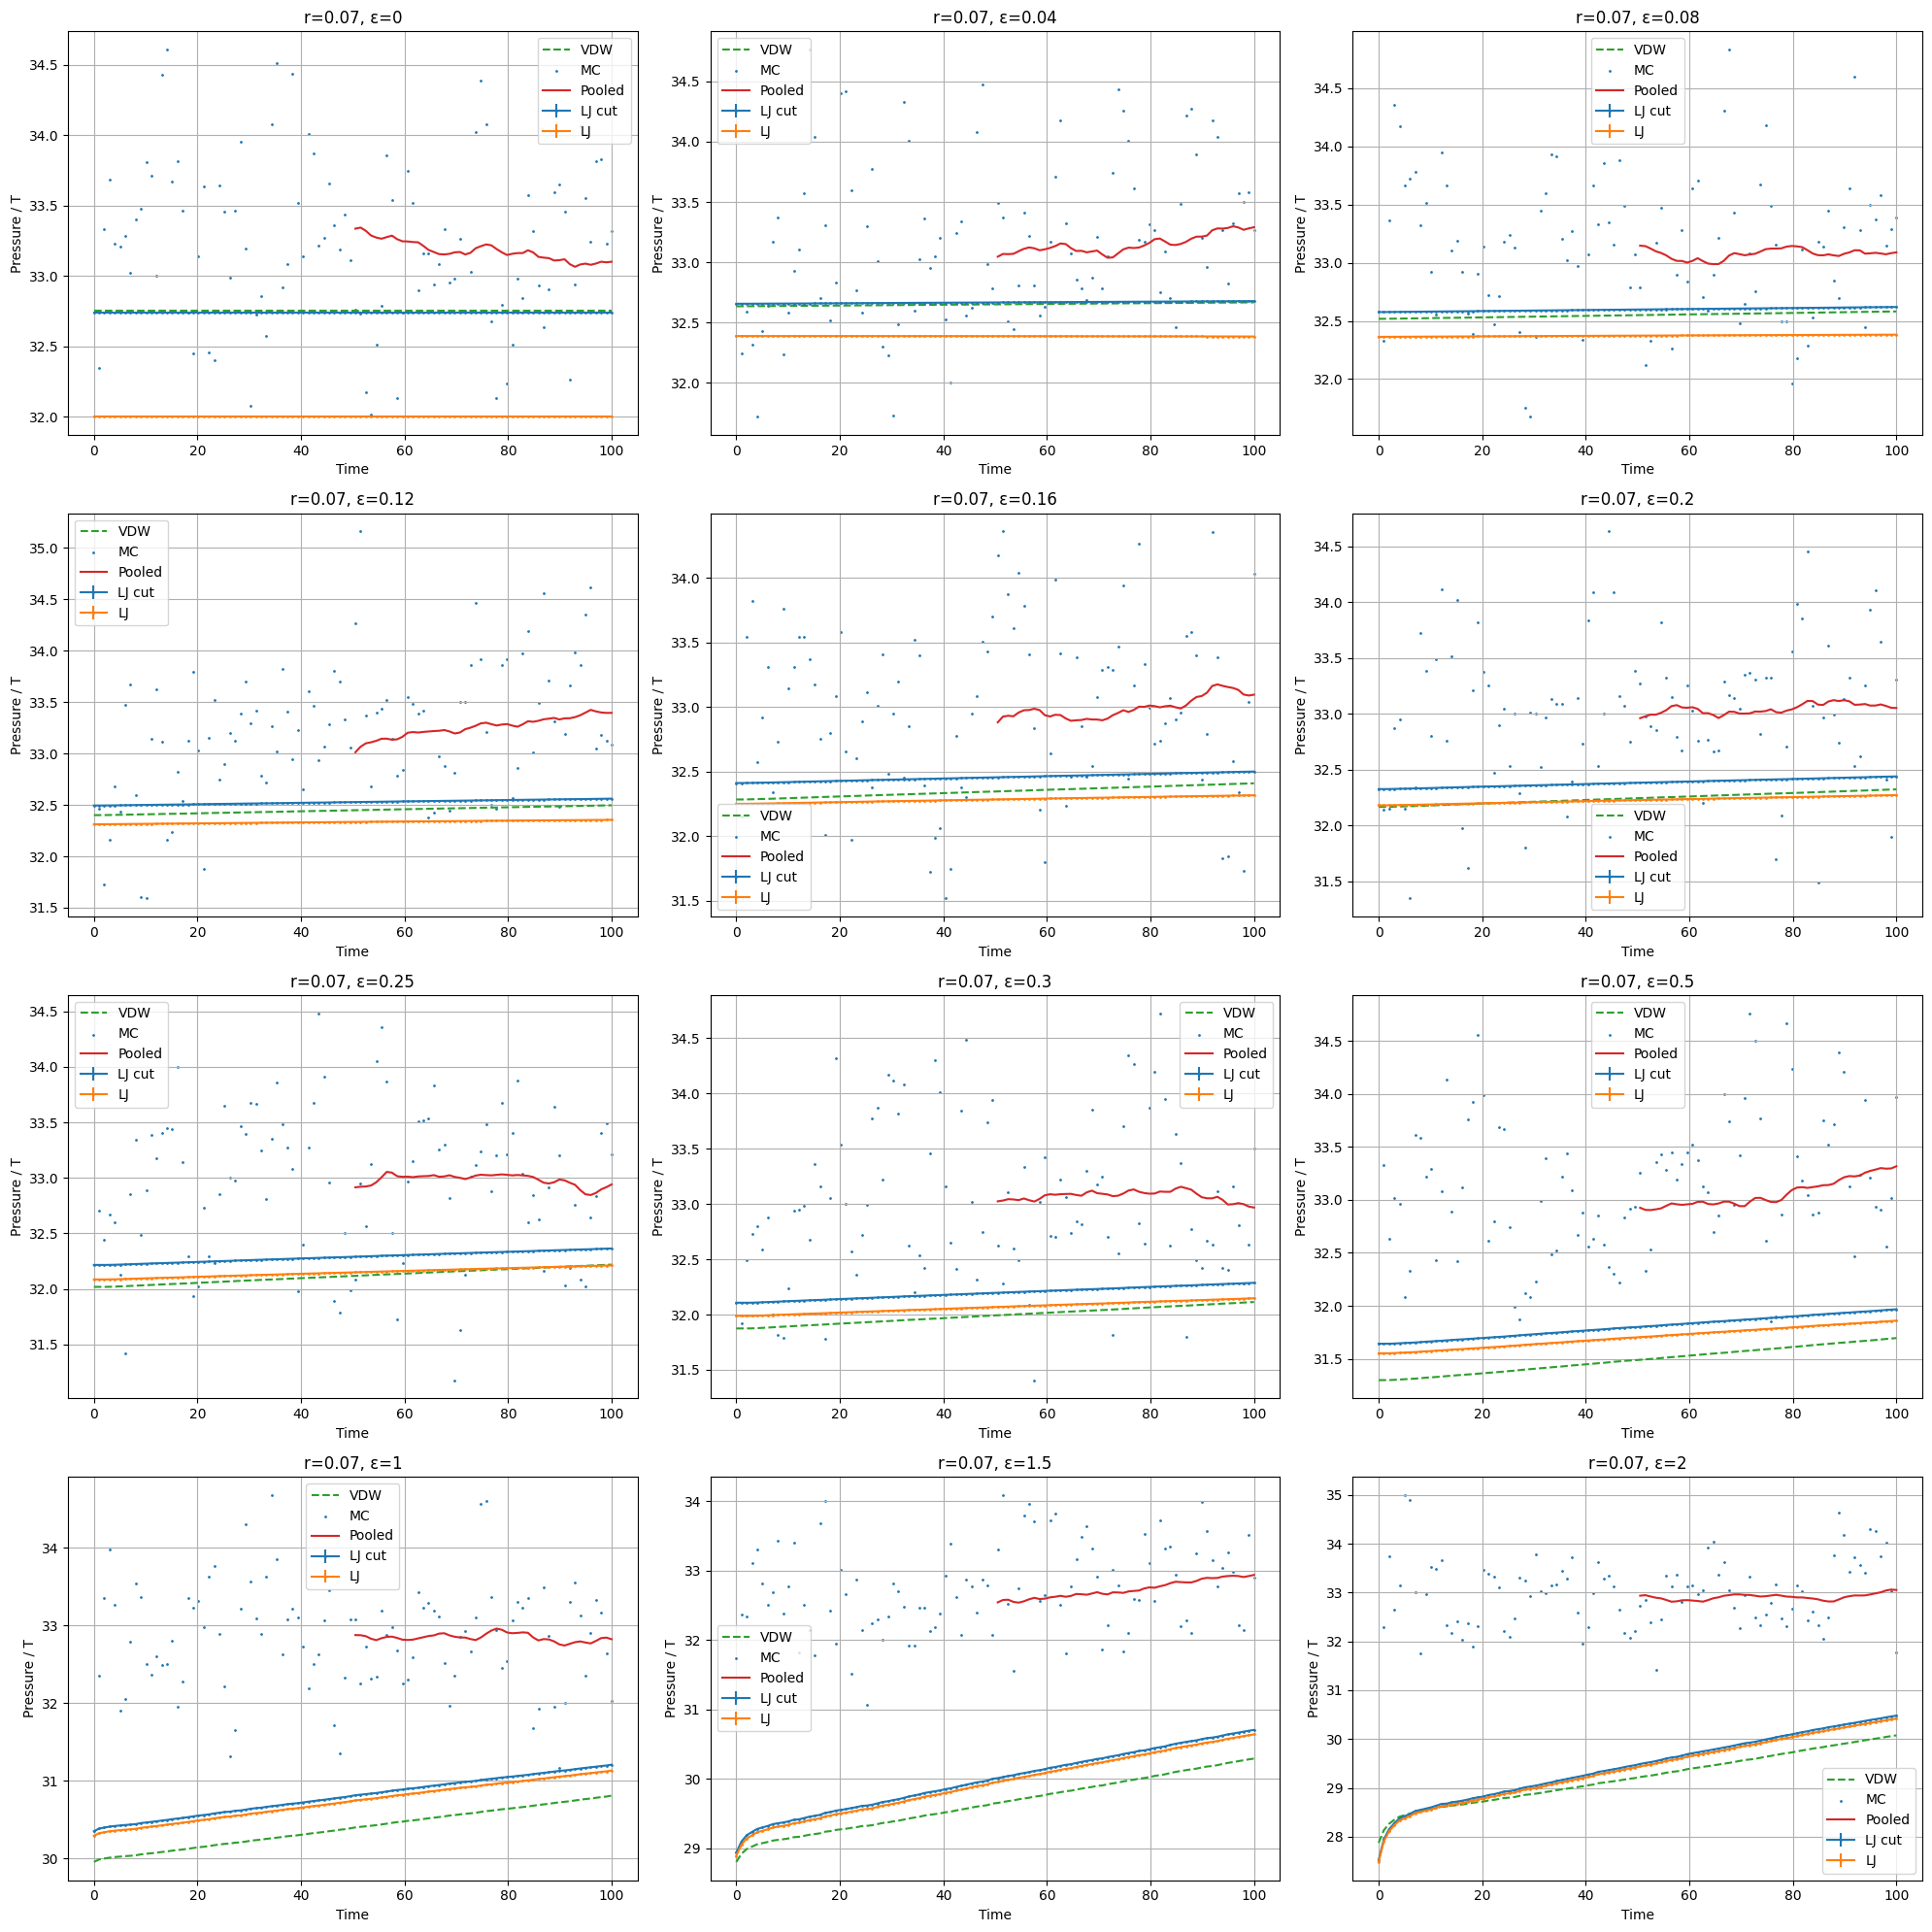

In [126]:
figs, axs = plt.subplots(4, 3, figsize=(20, 20))
for i, (d, p, e, r, ε, step) in enumerate(zip(dirs, pressures, energies, rs, eps, steps)):
    ax = axs[i // 3, i % 3]
    n = 32
    timeline = np.linspace(step.min(), step.max(), len(p))
    p_vdw = np.array([vdw(T, ε, r, n) for T in e])
    ax.errorbar(timeline, p_lj_cuts[i][:, 0] / e, yerr=p_lj_cuts[i][:, 1], label='LJ cut', fmt='-o', markersize=1)
    ax.errorbar(timeline, p_ljs[i][:, 0] / e, yerr=p_ljs[i][:, 1], label='LJ', fmt='-o', markersize=1)
    ax.plot(timeline, p_vdw / e, label='VDW', linestyle='--')
    ax.scatter(timeline[1:], p_per_Ts[i], label='MC', s=1)
    w = 50
    ax.plot(timeline[w:], np.convolve(p_per_Ts[i], np.ones(w), "valid") / w, label='Pooled')
    ax.set_title(f'r={r}, ε={ε}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Pressure / T')
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Pressure / T')

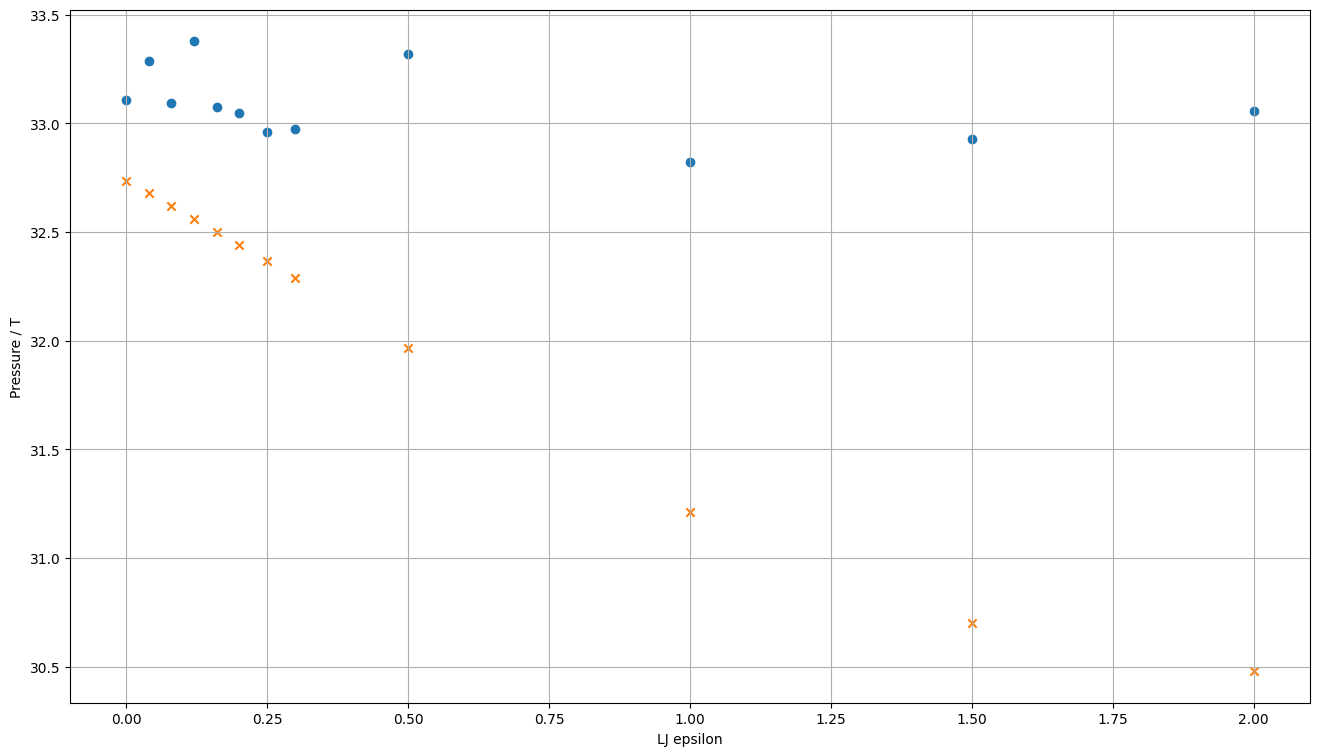

In [128]:
plt.figure(figsize=(16, 9))
plt.scatter(eps, [ppt[50:].mean() for ppt in p_per_Ts])
plt.scatter(eps, [plj[-1][0] / e[-1] for plj, e in zip(p_lj_cuts, energies)], marker='x')
# plt.xscale('log')
plt.grid()
plt.xlabel('LJ epsilon')
plt.ylabel('Pressure / T')